# 01 - TF-IDF + Cosine Similarity

## Deteccion de plagio en source code

Informacion del paper: Halim, Jimmy & Lasut, Desiyanna. (2024). Document Plagiarism Detection Application Using Web-Based TF-IDF and Cosine Similarity Methods: English. bit-Tech. 7. 202-213. 10.32877/bt.v7i2.1697.

La base metodológica es `Document_Plagiarism_Detection_Application_Using_Web-Based_TF-IDF_and_Cosine_Similarity_Methods` usa lowercasing, noise removal, tokenizacion/seleccion de terminos, TF-IDF con `idf = log10(N/df)` y Cosine Similarity para producir porcentaje de similitud.

## Preparación de datos y vectorización TF-IDF



In [13]:
import io, keyword, tokenize
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.model_selection import train_test_split

In [14]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd

In [15]:
DATA_URL = "hf://datasets/nop12/python_plagiarism_code_dataset/data/train-00000-of-00001.parquet"
PROJECT_DIR = Path("/kaggle/working/code-plagiarism-benchmark") if Path("/kaggle").exists() else Path.cwd() / "code-plagiarism-benchmark"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "models").mkdir(exist_ok=True)
(PROJECT_DIR / "figures").mkdir(exist_ok=True)
(PROJECT_DIR / "metrics").mkdir(exist_ok=True)
print(PROJECT_DIR)

df = pd.read_parquet(DATA_URL)
df["level_num"] = df["level"].str.extract(r"level(\d+)").astype("float")
print(df.shape)
print(df["level"].value_counts().sort_index())
display(df.head())

/kaggle/working/code-plagiarism-benchmark
(15176, 6)
level
level0      1770
level1      1932
level2      1932
level3      1928
level4      1892
level5      1915
level6      1859
original    1948
Name: count, dtype: int64


,model,assignment,level,code,filename,level_num
0,deep-seek-coder,assignment1,level0,"def get_key_by_index(dictionary: dict, index: ...",deepseek_aw_a_f_t_a_d_k_s_e_b_i1733686123.6054...,0.0
1,deep-seek-coder,assignment1,level1,"def access_key(ditionary,key):\n return lis...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,1.0
2,deep-seek-coder,assignment1,level2,"def get_key_value(mapping, index):\n return...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,2.0
3,deep-seek-coder,assignment1,level3,"def access_key(ditionary, key):\n # Retriev...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,3.0
4,deep-seek-coder,assignment1,level4,"def access_key(ditionary, key):\n keys_list...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,4.0


In [16]:
def build_pairs(data):
    originals = data[data["level"] == "original"][["model", "assignment", "code"]]
    originals = originals.rename(columns={"code": "code_a"})

    variants = data[data["level"].isin([f"level{i}" for i in range(1, 7)])]
    variants = variants[["model", "assignment", "level", "code"]]

    positives = variants.merge(originals, on=["model", "assignment"])
    positives = positives.rename(columns={"code": "code_b"})
    positives["label"] = 1

    other_originals = originals.drop_duplicates("assignment").sort_values("assignment")
    shifted_codes = other_originals["code_a"].shift(-1)
    shifted_codes.iloc[-1] = other_originals["code_a"].iloc[0]

    negative_map = dict(zip(other_originals["assignment"], shifted_codes))

    negatives = positives.copy()
    negatives["code_b"] = negatives["assignment"].map(negative_map)
    negatives["level"] = "negative"
    negatives["label"] = 0

    pairs = pd.concat([positives, negatives], ignore_index=True)
    return pairs[["assignment", "model", "level", "code_a", "code_b", "label"]]

In [17]:
assignments = pd.Series(df["assignment"].unique())

train_ids, temp_ids = train_test_split(assignments, test_size=0.30, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)

train_df = build_pairs(df[df["assignment"].isin(train_ids)])
val_df = build_pairs(df[df["assignment"].isin(val_ids)])
test_df = build_pairs(df[df["assignment"].isin(test_ids)])

In [18]:
def normalize_code(src):
    try:
        tokens = []
        reader = io.StringIO(str(src)).readline

        for tok in tokenize.generate_tokens(reader):
            t, s = tok.type, tok.string

            if t in {
                tokenize.COMMENT,
                tokenize.NL,
                tokenize.NEWLINE,
                tokenize.INDENT,
                tokenize.DEDENT,
                tokenize.ENCODING,
            }:
                continue

            if t == tokenize.NAME and not keyword.iskeyword(s):
                tokens.append("ID")
            elif t == tokenize.STRING:
                tokens.append("STR")
            elif t == tokenize.NUMBER:
                tokens.append("NUM")
            else:
                tokens.append(s)

        return " ".join(tokens)

    except tokenize.TokenError:
        return re.sub(r"\s+", " ", str(src))

In [19]:
for split in [train_df, val_df, test_df]:
    split["norm_a"] = split["code_a"].map(normalize_code)
    split["norm_b"] = split["code_b"].map(normalize_code)

In [20]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 8),
    sublinear_tf=True,
    max_features=50000
)

vectorizer.fit(pd.concat([train_df["norm_a"], train_df["norm_b"]]))

TfidfVectorizer(analyzer='char_wb', max_features=50000, ngram_range=(3, 8),
                sublinear_tf=True)

## Entrenamiento de modelos

In [21]:
def get_scores(data):
    a = vectorizer.transform(data["norm_a"])
    b = vectorizer.transform(data["norm_b"])
    return 1 - paired_cosine_distances(a, b)

In [22]:
val_scores = get_scores(val_df)

best_t = 0
best_f1 = 0

for t in np.linspace(0.05, 0.95, 181):
    preds = (val_scores >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        val_df["label"],
        preds,
        average="binary",
        zero_division=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Validation F1:", best_f1)

Best threshold: 0.705
Validation F1: 0.880071599045346


## Evaluación del modelo

In [23]:
test_scores = get_scores(test_df)
test_preds = (test_scores >= best_t).astype(int)

p, r, f1, _ = precision_recall_fscore_support(
    test_df["label"],
    test_preds,
    average="binary",
    zero_division=0
)

metrics = {
    "accuracy": accuracy_score(test_df["label"], test_preds),
    "recall": r,
    "f1": f1,
    "threshold": best_t,
}

metrics

{'accuracy': 0.8724852071005917,
 'recall': 0.8710059171597633,
 'f1': 0.8722962962962963,
 'threshold': np.float64(0.705)}

## Confusion Matrix

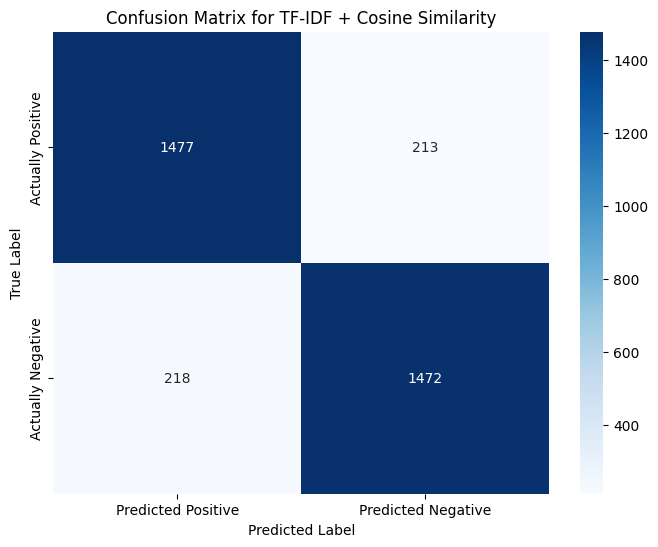

In [24]:
cm = confusion_matrix(test_df["label"], test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Predicted Positive", "Predicted Negative"],
    yticklabels=["Actually Positive", "Actually Negative"]
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for TF-IDF + Cosine Similarity')
plt.show()

## Entrenamiento vectorial

Hiperparametros alineados al paper: lowercasing, noise removal, tokenizacion por terminos, TF-IDF sin normalizar y `idf = log10(N/df)`. Por defecto no se recorta vocabulario; puedes activar seleccion de features cambiando `MAX_FEATURES`, `MIN_DF` o `MAX_DF`.

## Evaluacion

La prediccion es el `uid` del codigo de entrenamiento con mayor similitud coseno.